![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz, DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score



In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [7]:
# Celda 1.1
bikes.groupby('season').total.mean()

,total
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


#### Análisis Punto 1.1.

Teniendo en cuenta que en el diccionario de datos se especifica que las estaciones corresponden a 1: winter (invierno), 2: spring (primavera), 3: summer (verano) y 4: fall (otoño), se observa que la demanda es menor en invierno (116), aumenta en primavera (215) y alcanza su máximo en verano (234), para luego disminuir en otoño (198). Esto muestra que el uso de bicicletas está fuertemente influenciado por el clima, con mayor actividad en estaciones cálidas.

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

,total
hour,
0,55.138462
1,33.859031
2,22.899554
3,11.757506
4,6.407240
5,19.767699
6,76.259341
7,213.116484
8,362.769231


#### Análisis punto 1.2.
La variable hour (0 a 23) muestra un patrón claro de comportamiento diario en la demanda. Durante la madrugada (0–5 h) la demanda es muy baja, alcanzando sus valores mínimos entre las 2 y 4 am, lo que es consistente con horarios de baja actividad urbana. A partir de las 6 h se observa un crecimiento pronunciado que lleva a un primer pico en la mañana (7–9 h), asociado a desplazamientos hacia el trabajo o estudio. Posteriormente, la demanda se mantiene relativamente alta durante el día, con cierta estabilidad entre las 10 y 16 h. El mayor pico ocurre en la tarde (17–18 h), superando incluso el de la mañana, lo que sugiere un uso intensivo en el regreso a casa. Finalmente, la demanda decrece progresivamente en la noche (19–23 h).


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

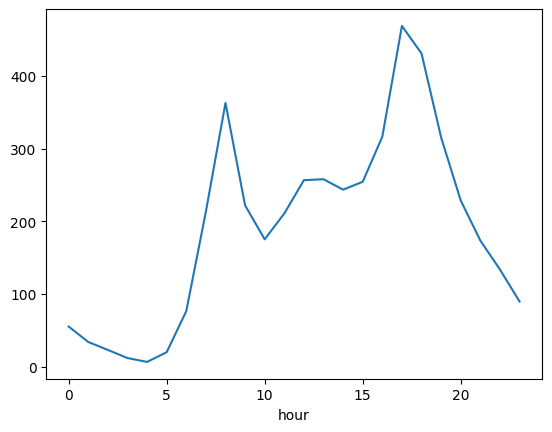

In [11]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

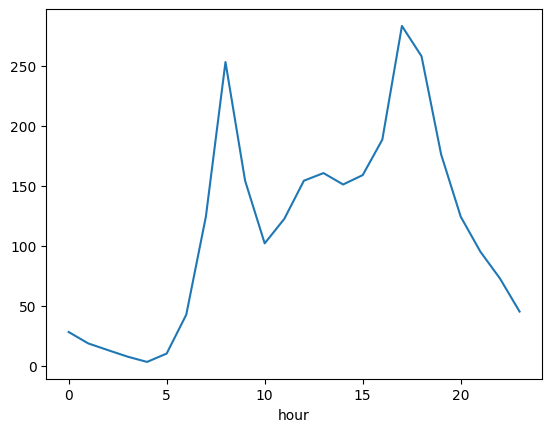

In [14]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos

bikes[bikes['season']==1].groupby('hour').total.mean().plot()

In [17]:
bikes[bikes['season']==1].groupby('hour').total.mean().max()

283.4561403508772

#### Hallazgos punto 2.2.

Invierno (season = 1 winter)
El patrón horario mantiene la forma general observada en el agregado de todas las estaciones: baja demanda en la madrugada, incremento desde las primeras horas del día, pico en la mañana (cerca de las 8 am), ligera caída al mediodía y segundo pico en la tarde (entre las 3 y las 5 pm), seguido de una disminución en la noche. Sin embargo, en invierno la intensidad es menor en todas las horas, y los picos son menos pronunciados, lo que indica un uso reducido del sistema aunque conservando la misma dinámica de movilidad, asi mismo se observa en el eje Y que el maximo de usos promedio es de aproximadamente 283.

<Axes: xlabel='hour'>

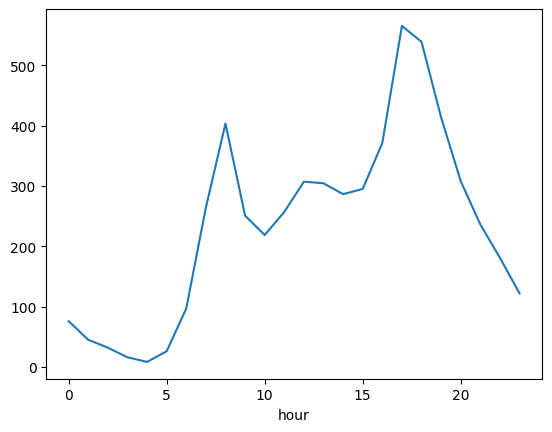

In [15]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
bikes[bikes['season']==3].groupby('hour').total.mean().plot()

In [18]:
bikes[bikes['season']==3].groupby('hour').total.mean().max()

565.3859649122807

#### Hallazgos punto 2.3.
Verano (season = 3 summer)
El patrón también sigue la misma estructura los anteriores en el comportamiento general, pero con una intensidad mucho mayor. Los picos de la mañana y especialmente de la tarde son más altos y más amplios, y la demanda se mantiene elevada durante gran parte del día. Esto sugiere que la estacionalidad no altera el patrón de uso, sino que amplifica la demanda, haciendo más evidente el comportamiento observado en el agregado, y además el maximo reflejado de usos es de aproximadamente 565 lo que es considerablemente mayor que en invierno.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [19]:
# Celda 3
bikes.dtypes

,0
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64
registered,int64


In [20]:
X = bikes[['season','hour']]
X = pd.get_dummies(X, columns=['season'], drop_first=True)

y = bikes['total']

model = LinearRegression()
model.fit(X, y)

print("Intercepto:", model.intercept_)
print("Coeficientes:")
for name, coef in zip(X.columns, model.coef_):
    print(name, coef)

Intercepto: -6.430262462305961
Coeficientes:
hour 10.545206094069897
season_2 100.31723191606571
season_3 119.46754994593174
season_4 84.08311787296768


#### Análisis regresion

El intercepto (-6.43) representa la demanda estimada cuando la hora es 0 y la estacion es 1 (invierno). Este valor no tiene una interpretación práctica fuerte, ya que el modelo es lineal y la demanda real no sigue un comportamiento lineal en el tiempo.

El coeficiente de la variable hour (10.55) indica que, según el modelo, por cada incremento de una hora la demanda aumenta en aproximadamente 10.5 bicicletas. Sin embargo, este resultado simplifica en exceso la realidad, ya que en los datos se observa un comportamiento no lineal con picos en la mañana y en la tarde.

Los coeficientes de las variables de temporada representan el cambio en la demanda respecto a la categoría base (invierno). En primavera (season_2) la demanda aumenta en aproximadamente 100 bicicletas, en verano (season_3) en aproximadamente 119 bicicletas y en otoño (season_4) en aproximadamente 84 bicicletas. Esto confirma que la demanda es mayor en estaciones más cálidas.

En conjunto, el modelo logra capturar el efecto de la estacionalidad sobre la demanda, pero presenta limitaciones importantes al representar la variación horaria, ya que asume una relación lineal que no refleja el comportamiento real observado en los datos.

La principal desventaja es que la regresión lineal asume relaciones lineales entre las variables y la respuesta. En este caso, la demanda no crece de forma lineal con la hora, sino que presenta picos y caídas, por lo que el modelo no captura correctamente ese comportamiento.

Además, al usar hour como variable numérica, no se considera su naturaleza cíclica (0 y 23 están cerca en el tiempo, pero el modelo los trata como lejanos). Esto genera errores en la estimación.

También se ignoran posibles interacciones entre variables, como que el efecto de la hora cambia según la estación. En conjunto, esto limita la capacidad del modelo para representar patrones reales de la demanda.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [72]:
# Celda 4
max_depth = 4      # profundidad para 6 nodos
num_pct   = 10     # percentiles como candidatos de corte
min_gain  = 0.001  # ganancia mínima para seguir dividiendo

In [73]:
X = bikes[['hour', 'season']].copy()
y = bikes['total'].copy()
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [74]:
def variance(y):

    if len(y) == 0:
        return 0
    return y.var()

In [75]:
def variance_gain(X_col, y, split):

    filter_l = X_col < split
    y_l = y[filter_l]
    y_r = y[~filter_l]

    n   = len(y)
    n_l = len(y_l)
    n_r = len(y_r)

    if n_l == 0 or n_r == 0:
        return 0

    gain = variance(y) - (n_l / n * variance(y_l) + n_r / n * variance(y_r))
    return gain

In [76]:
def best_split(X, y, num_pct=10):
    result = [0, 0, 0]

    for j in range(X.shape[1]):
        splits = np.percentile(
            X.iloc[:, j],
            np.arange(0, 100, 100.0 / (num_pct + 1)).tolist()
        )
        splits = np.unique(splits)[1:]

        for split in splits:
            gain = variance_gain(X.iloc[:, j], y, split)
            if gain > result[2]:
                result = [j, split, gain]

    return result

In [77]:
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):

    if len(y) <= 1:
        return dict(y_pred=y.mean(), level=level,
                    split=-1, n_samples=len(y), gain=0)

    j, split, gain = best_split(X, y, num_pct)

    y_pred = y.mean()

    node = dict(
        y_pred    = y_pred,
        level     = level,
        split     = -1,
        n_samples = len(y),
        gain      = round(gain, 6),
        feature   = X.columns[j] if gain >= min_gain else None
    )


    if gain < min_gain:
        return node
    if max_depth is not None and level >= max_depth:
        return node

    filter_l = X.iloc[:, j] < split
    X_l, y_l = X[filter_l],  y[filter_l]
    X_r, y_r = X[~filter_l], y[~filter_l]

    node['split']   = [j, split]
    node['feature'] = X.columns[j]

    node['sl'] = tree_grow(X_l, y_l, level + 1,
                           min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    node['sr'] = tree_grow(X_r, y_r, level + 1,
                           min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    return node

In [78]:
def tree_predict(X, tree):

    predicted = np.zeros(len(X))

    if tree['split'] == -1:
        predicted[:] = tree['y_pred']
        return predicted

    j, split = tree['split']
    filter_l  = X.iloc[:, j] < split
    X_l = X[filter_l]
    X_r = X[~filter_l]

    if len(X_l) > 0:
        predicted[filter_l.values]  = tree_predict(X_l.reset_index(drop=True), tree['sl'])
    if len(X_r) > 0:
        predicted[~filter_l.values] = tree_predict(X_r.reset_index(drop=True), tree['sr'])

    return predicted

In [79]:
tree = tree_grow(X, y, level=0, min_gain=min_gain,
                 max_depth=max_depth, num_pct=num_pct)

In [80]:
y_pred = tree_predict(X, tree)

mse_manual = np.mean((y - y_pred) ** 2)
print(f"MSE del árbol de regresión: {mse_manual:.4f}")

MSE del árbol de regresión: 15677.7029


In [81]:
def count_leaves(tree):
    if tree['split'] == -1:
        return 1
    return count_leaves(tree['sl']) + count_leaves(tree['sr'])

print(f"Número de nodos hoja: {count_leaves(tree)}")

Número de nodos hoja: 14


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [7]:
# Celda 5
X = bikes[['season', 'hour']].copy()
y = bikes['total'].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tree_sk = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree_sk.fit(X_train, y_train)

y_pred_train = tree_sk.predict(X_train)
y_pred_val   = tree_sk.predict(X_val)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_val   = mean_squared_error(y_val,   y_pred_val)

print("_______ Árbol sklearn _______")
print(f"MSE  Train      : {mse_train:.4f}")
print(f"MSE  Validación : {mse_val:.4f}")
print(f"Nodos hoja      : {tree_sk.get_n_leaves()}")
print(f"Profundidad real: {tree_sk.get_depth()}")


NameError: name 'bikes' is not defined

In [83]:

y_pred_manual = tree_predict(X.reset_index(drop=True), tree)

print("\n____ Comparación de desempeño (MSE) _______")
print(f"Árbol manual           : {mse_manual:.4f}")
print(f"Árbol sklearn          : {mse_val:.4f}")
print(f"Mejora                 : {((mse_manual - mse_val) / mse_manual * 100):.1f}%")


____ Comparación de desempeño (MSE) _______
Árbol manual           : 15677.7029
Árbol sklearn          : 13453.8509
Mejora                 : 14.2%


Para evaluar el desempeño de los modelos se utilizó el Error Cuadrático Medio (MSE), métrica estándar en problemas de regresión que penaliza con mayor peso los errores grandes.
El árbol de decisión implementado con sklearn obtuvo un MSE de 13,453 sobre el conjunto de validación, superando al árbol construido manualmente en celda 4, cuyo MSE fue de 15,677, lo que representa una mejora del 14%. Esta diferencia se atribuye principalmente a la mayor profundidad permitida en el modelo de sklearn (max_depth=10 frente a max_depth=4), así como al uso de parámetros de regularización como min_samples_leaf y min_samples_split, que permiten un mejor control del sobreajuste. No obstante, ambos modelos se restringen a dos variables predictoras (hour y season), lo que limita su capacidad explicativa. Un MSE de ~13,000 sobre el total de bicicletas rentadas indica que aún existe un margen considerable de mejora, el cual podría reducirse incorporando variables adicionales.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [8]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [12]:
df.columns


Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [16]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [17]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [32]:
print(df['Popular'].value_counts())
print(f"\nProporción:\n{df['Popular'].value_counts(normalize=True).round(4)}")

Popular
1    3000
0    3000
Name: count, dtype: int64

Proporción:
Popular
1    0.5
0    0.5
Name: proportion, dtype: float64


### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [20]:
# Celda 6
# Arbol de decision

print("─── Calibración max_depth (Árbol) ───────────────")
for depth in [3, 5, 10, 15, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    f1  = f1_score(y_test, clf.predict(X_test))
    print(f"max_depth={str(depth):<5} → Accuracy: {acc:.4f} | F1: {f1:.4f}")


─── Calibración max_depth (Árbol) ───────────────
max_depth=3     → Accuracy: 0.6413 | F1: 0.6073
max_depth=5     → Accuracy: 0.6373 | F1: 0.6617
max_depth=10    → Accuracy: 0.5713 | F1: 0.5811
max_depth=15    → Accuracy: 0.5607 | F1: 0.5707
max_depth=None  → Accuracy: 0.5420 | F1: 0.5411


In [27]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=1)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree  = f1_score(y_test, y_pred_tree)

In [28]:
print(y_pred_tree)
print(acc_tree)
print(f1_tree)

[1 1 1 ... 1 0 0]
0.6413333333333333
0.6072992700729927


In [30]:
# Regresion logistica

log_reg = LogisticRegression(max_iter=1000, random_state=1)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
f1_log  = f1_score(y_test, y_pred_log)

print(y_pred_log)
print(acc_log)
print(f1_log)

[1 1 1 ... 1 0 0]
0.6133333333333333
0.6032831737346102


In [31]:
print(f"{'Modelo':<25} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Árbol de decisión':<25} {acc_tree:>10.4f} {f1_tree:>10.4f}")
print(f"{'Regresión logística':<25} {acc_log:>10.4f} {f1_log:>10.4f}")

Modelo                      Accuracy   F1-Score
Árbol de decisión             0.6413     0.6073
Regresión logística           0.6133     0.6033


#### Análisis
Las clases están perfectamente balanceadas (50% popular, 50% no popular), lo que significa que un clasificador aleatorio obtendría un Accuracy del 50%. Bajo ese contexto, ambos modelos mejoran la línea base pero de forma moderada.
El árbol de decisión con max_depth=5 obtuvo un Accuracy de 0.6413 y F1-Score de 0.6073, superando levemente a la regresión logística con 0.6133 y 0.6033 respectivamente. Dado el balance de clases, Accuracy y F1-Score son igualmente válidos como métricas, y ambos apuntan al árbol de decisión como el modelo con mejor desempeño.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados.

Nota:

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100 * 55%+100 * 55%+100 * 10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [34]:
# Celda 7
# Primero vamos a calibrar los dos arboles con los parametros solicitados max_depth y min_samples_leaf

# Calibración max_depth
print(" Calibración max_depth ")
for depth in [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    f1  = f1_score(y_test, clf.predict(X_test))
    print(f"max_depth={str(depth):<5} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

# Calibración min_samples_leaf
print("\n Calibración min_samples_leaf ")
for leaf in [1, 5, 10, 20, 50, 100, 150, 200, 300, 500]:
    clf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=1)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    f1  = f1_score(y_test, clf.predict(X_test))
    print(f"min_samples_leaf={str(leaf):<5} → Accuracy: {acc:.4f} | F1: {f1:.4f}")


 Calibración max_depth 
max_depth=1     → Accuracy: 0.6453 | F1: 0.6449
max_depth=2     → Accuracy: 0.6453 | F1: 0.6449
max_depth=3     → Accuracy: 0.6413 | F1: 0.6073
max_depth=4     → Accuracy: 0.6513 | F1: 0.6345
max_depth=5     → Accuracy: 0.6373 | F1: 0.6617
max_depth=6     → Accuracy: 0.6247 | F1: 0.6209
max_depth=7     → Accuracy: 0.6207 | F1: 0.6355
max_depth=8     → Accuracy: 0.6087 | F1: 0.6338
max_depth=10    → Accuracy: 0.5713 | F1: 0.5811
max_depth=15    → Accuracy: 0.5607 | F1: 0.5707

 Calibración min_samples_leaf 
min_samples_leaf=1     → Accuracy: 0.5420 | F1: 0.5411
min_samples_leaf=5     → Accuracy: 0.5353 | F1: 0.5411
min_samples_leaf=10    → Accuracy: 0.5727 | F1: 0.5666
min_samples_leaf=20    → Accuracy: 0.5707 | F1: 0.5503
min_samples_leaf=50    → Accuracy: 0.6167 | F1: 0.6128
min_samples_leaf=100   → Accuracy: 0.6533 | F1: 0.6583
min_samples_leaf=150   → Accuracy: 0.6587 | F1: 0.6623
min_samples_leaf=200   → Accuracy: 0.6687 | F1: 0.6856
min_samples_leaf=300   →

In [37]:
n_estimators = 100
n_samples = X_train.shape[0]
np.random.seed(123)

In [38]:

# Muestras
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True)
           for _ in range(300)]

np.random.seed(123)
seeds = np.random.randint(1, 10000, size=300)

# Guardar predicciones
y_pred_df = pd.DataFrame(index=X_test.index, columns=list(range(300)))

# árboles con max_depth=5
trees_1 = {}
for i in range(100):
    trees_1[i] = DecisionTreeClassifier(max_depth=5, random_state=seeds[i])
    trees_1[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df.iloc[:, i] = trees_1[i].predict(X_test)

#  Grupo 2: 100 árboles con min_samples_leaf=200
trees_2 = {}
for i in range(100, 200):
    trees_2[i] = DecisionTreeClassifier(min_samples_leaf=200, random_state=seeds[i])
    trees_2[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df.iloc[:, i] = trees_2[i].predict(X_test)

#  Grupo 3: 100 regresiones logísticas
logs = {}
for i in range(200, 300):
    logs[i] = LogisticRegression(max_iter=1000, random_state=seeds[i])
    logs[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df.iloc[:, i] = logs[i].predict(X_test)

#  Evaluación individual de cada grupo
# Votación mayoritaria por grupo
y_pred_g1 = (y_pred_df.iloc[:, :100].sum(axis=1) >= 50).astype(int)
y_pred_g2 = (y_pred_df.iloc[:, 100:200].sum(axis=1) >= 50).astype(int)
y_pred_g3 = (y_pred_df.iloc[:, 200:].sum(axis=1) >= 50).astype(int)

print(" Desempeño individual por grupo ")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Árboles max_depth=5':<35} {accuracy_score(y_test, y_pred_g1):>10.4f} {f1_score(y_test, y_pred_g1):>10.4f}")
print(f"{'Árboles min_samples_leaf=200':<35} {accuracy_score(y_test, y_pred_g2):>10.4f} {f1_score(y_test, y_pred_g2):>10.4f}")
print(f"{'Regresiones logísticas':<35} {accuracy_score(y_test, y_pred_g3):>10.4f} {f1_score(y_test, y_pred_g3):>10.4f}")


 Desempeño individual por grupo 
Modelo                                Accuracy   F1-Score
Árboles max_depth=5                     0.6547     0.6528
Árboles min_samples_leaf=200            0.6700     0.6720
Regresiones logísticas                  0.6180     0.6062


In [40]:
#Votación mayoritaria sobre los 300 modelos

y_pred_ensamble = (y_pred_df.sum(axis=1) >= 150).astype(int)

print(f"\n Desempeño ensamble (300 modelos) ")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Ensamble votación mayoritaria':<35} {accuracy_score(y_test, y_pred_ensamble):>10.4f} {f1_score(y_test, y_pred_ensamble):>10.4f}")


─── Desempeño ensamble (300 modelos) ────────────────────
Modelo                                Accuracy   F1-Score
Ensamble votación mayoritaria           0.6507     0.6426


#### Análisis

El grupo de árboles con min_samples_leaf=200 es el de mejor desempeño individual con un F1-Score de 0.6720, seguido por los árboles con max_depth=5 (0.6528). Las regresiones logísticas son el grupo más débil, con el menor Accuracy (0.6180) y F1-Score (0.6062) de los tres grupos.
El ensamble de 300 modelos obtiene un F1-Score de 0.6426, que no logra superar al mejor grupo individual. Esto se explica porque las regresiones logísticas, al tener el peor desempeño individual, pesan igual que los otros grupos en la votación, arrastrando el resultado final hacia abajo y diluyendo la contribución de los árboles con min_samples_leaf=200. Esto ilustra una limitación de la votación mayoritaria con pesos iguales: mezclar modelos con desempeños muy distintos no garantiza superar al mejor modelo individual.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [ ]:
# Celda 8


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [ ]:
# Celda 9